# NumPy Basics Arrays and Vectorized Computation

To give you an idea of the performance difference, consider a NumPy array of one
million integers, and the equivalent Python list:

In [1]:
import numpy as np

In [2]:
my_arr = np.arange(1000000)

In [3]:
my_list = list(range(1000000))

In [4]:
%time for _ in range(10): my_arr2 = my_arr *2

CPU times: total: 31.2 ms
Wall time: 34 ms


In [5]:
%time for _ in range(10): my_list2 = [x * 2 for x in my_list]

CPU times: total: 1.19 s
Wall time: 1.23 s


NumPy-based algorithms are generally 10 to 100 times faster (or more) than their
pure Python counterparts and use significantly less memory.


# **4.1 The NumPy ndarray: A Multidimensional Array Object**

One of the key features of NumPy is its N-dimensional array object, or ndarray,
which is a fast, flexible container for large datasets in Python. Arrays enable you to perform mathematical operations on whole blocks of data using similar syntax to the equivalent operations between scalar elements.

To give you a flavor of how NumPy enables batch computations with similar syntax
to scalar values on built-in Python objects, I first import NumPy and generate a small array of random data:

In [6]:
import numpy as np

In [7]:
data = np.random.randn(2,3)

In [8]:
data

array([[-0.34482328, -1.51238283, -1.03557839],
       [-0.75297851, -0.45910799,  0.91722569]])

I then write mathematical operations with data:

In [9]:
data * 10

array([[ -3.44823283, -15.12382828, -10.35578388],
       [ -7.52978509,  -4.59107994,   9.17225691]])

In [10]:
data + data

array([[-0.68964657, -3.02476566, -2.07115678],
       [-1.50595702, -0.91821599,  1.83445138]])

In the first example, all of the elements have been multiplied by 10. In the second, the corresponding values in each “cell” in the array have been added to each other.

An ndarray is a generic multidimensional container for homogeneous data; that is, all
of the elements must be the same type. Every array has a shape, a tuple indicating the size of each dimension, and a dtype, an object describing the data type of the array:

In [11]:
data.shape

(2, 3)

In [12]:
data.dtype

dtype('float64')

# Creating ndarrays

The easiest way to create an array is to use the array function. This accepts any
sequence-like object (including other arrays) and produces a new NumPy array containing the passed data. For example, a list is a good candidate for conversion:

In [13]:
data1 = [6, 7.5, 8, 0, 1]

In [14]:
arr1 = np.array(data1)

In [15]:
arr1

array([6. , 7.5, 8. , 0. , 1. ])

Nested sequences, like a list of equal-length lists, will be converted into a multidimensional array:

In [16]:
data2 = [[1,2,3,4], [5,6,7,8]]

In [17]:
arr2 = np.array(data2)

In [18]:
arr2

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

Since data2 was a list of lists, the NumPy array arr2 has two dimensions with shape
inferred from the data. We can confirm this by inspecting the ndim and shape
attributes:

In [19]:
arr2.ndim

2

In [20]:
arr2.shape

(2, 4)

Unless explicitly specified (more on this later), np.array tries to infer a good data
type for the array that it creates. The data type is stored in a special dtype metadata
object; for example, in the previous two examples we have:

In [21]:
arr1.dtype

dtype('float64')

In [22]:
arr2.dtype

dtype('int32')

In addition to np.array, there are a number of other functions for creating new
arrays. As examples, zeros and ones create arrays of 0s or 1s, respectively, with a
given length or shape. empty creates an array without initializing its values to any particular value. To create a higher dimensional array with these methods, pass a tuple for the shape:

In [23]:
np.zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [24]:
np.zeros((3,6))

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [25]:
np.empty((2, 3, 2))

array([[[8.39281861e-312, 3.16202013e-322],
        [0.00000000e+000, 0.00000000e+000],
        [1.29060531e-306, 3.40095973e+175]],

       [[1.08602083e-071, 3.12165518e-033],
        [2.16696004e+184, 9.96010789e-043],
        [6.56373928e+169, 2.35743281e+184]]])

arange is an array-valued version of the built-in Python range function:

In [26]:
np.arange(15)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

See Table 4-1 for a short list of standard array creation functions. Since NumPy is
focused on numerical computing, the data type, if not specified, will in many cases be float64 (floating point).

![alt text](Data/7.JPG)

# Data Types for ndarrays

The data type or dtype is a special object containing the information (or metadata,
data about data) the ndarray needs to interpret a chunk of memory as a particular
type of data:

In [27]:
arr1 = np.array([1,2,3],dtype=np.float64)

In [28]:
arr2 = np.array([1,2,3],dtype=np.int32)

In [29]:
arr1.dtype

dtype('float64')

In [30]:
arr2.dtype

dtype('int32')

Table 4-2. NumPy data types

![alt text](Data/2.JPG)

You can explicitly convert or cast an array from one dtype to another using ndarray’s
astype method:


In [31]:
arr = np.array([1,2,3,4,5])

In [32]:
arr.dtype

dtype('int32')

In [33]:
float_arr = arr.astype(np.float64)

In [34]:
float_arr.dtype

dtype('float64')

If you have an array of strings representing numbers, you can use astype to convert
them to numeric form:

In [35]:
numeric_strings = np.array(['1.25','-9.6','42'],dtype=np.string_)

In [36]:
numeric_strings.astype(float)

array([ 1.25, -9.6 , 42.  ])

If casting were to fail for some reason (like a string that cannot be converted to
float64), a ValueError will be raised. Here I was a bit lazy and wrote float instead
of np.float64; NumPy aliases the Python types to its own equivalent data dtypes.

You can also use another array’s dtype attribute:

In [37]:
int_array = np.arange(10)

In [38]:
calibars = np.array([.22, .270, .357, .380, .44, .50], dtype=np.float64)

In [39]:
int_array.astype(calibars.dtype)

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

There are shorthand type code strings you can also use to refer to a dtype:

In [40]:
empty_uint32 = np.empty(8,dtype='u4')

In [41]:
empty_uint32

array([         0, 1075314688,          0, 1075707904,          0,
       1075838976,          0, 1072693248], dtype=uint32)

# Arithmetic with NumPy Arrays

Arrays are important because they enable you to express batch operations on data
without writing any for loops. NumPy users call this vectorization. Any arithmetic
operations between equal-size arrays applies the operation element-wise:

In [42]:
arr = np.array([[1.,2.,3.],[4.,5.,6.]])

In [43]:
arr

array([[1., 2., 3.],
       [4., 5., 6.]])

In [44]:
arr*arr

array([[ 1.,  4.,  9.],
       [16., 25., 36.]])

In [45]:
arr-arr

array([[0., 0., 0.],
       [0., 0., 0.]])

Arithmetic operations with scalars propagate the scalar argument to each element in
the array:

In [46]:
1/arr

array([[1.        , 0.5       , 0.33333333],
       [0.25      , 0.2       , 0.16666667]])

In [47]:
arr ** 0.5

array([[1.        , 1.41421356, 1.73205081],
       [2.        , 2.23606798, 2.44948974]])

Comparisons between arrays of the same size yield boolean arrays:

In [48]:
arr2 = np.array([[0., 4., 1.], [7., 2., 12.]])

In [49]:
arr2

array([[ 0.,  4.,  1.],
       [ 7.,  2., 12.]])

In [50]:
arr2 > arr

array([[False,  True, False],
       [ True, False,  True]])

# Basic Indexing and Slicing

NumPy array indexing is a rich topic, as there are many ways you may want to select
a subset of your data or individual elements. One-dimensional arrays are simple; on
the surface they act similarly to Python lists:

In [51]:
import numpy as np

In [52]:
arr = np.arange(10)

In [53]:
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [54]:
arr[5]

5

In [55]:
arr[5:8]

array([5, 6, 7])

In [56]:
arr[5:8] = 12

In [57]:
arr

array([ 0,  1,  2,  3,  4, 12, 12, 12,  8,  9])

As you can see, if you assign a scalar value to a slice, as in arr[5:8] = 12, the value is propagated (or broadcasted henceforth) to the entire selection. An important first distinction from Python’s built-in lists is that array slices are views on the original array. This means that the data is not copied, and any modifications to the view will be reflected in the source array.

To give an example of this, I first create a slice of arr:

In [58]:
arr_slice = arr[5:8]

In [59]:
arr_slice

array([12, 12, 12])

Now, when I change values in arr_slice, the mutations are reflected in the original
array arr:

In [60]:
arr_slice[1] = 12345

In [61]:
arr

array([    0,     1,     2,     3,     4,    12, 12345,    12,     8,
           9])

The “bare” slice [:] will assign to all values in an array:

In [62]:
arr_slice[:] = 64

In [63]:
arr

array([ 0,  1,  2,  3,  4, 64, 64, 64,  8,  9])

If you are new to NumPy, you might be surprised by this, especially if you have used
other array programming languages that copy data more eagerly. As NumPy has been
designed to be able to work with very large arrays, you could imagine performance
and memory problems if NumPy insisted on always copying data.

If you want a copy of a slice of an ndarray instead of a view, you
will need to explicitly copy the array—for example,
arr[5:8].copy().

In [64]:
arr[5:8].copy()

array([64, 64, 64])

With higher dimensional arrays, you have many more options. In a two-dimensional
array, the elements at each index are no longer scalars but rather one-dimensional
arrays:

In [104]:
arr2d = np.array([[1,2,3],[4,5,6],[7,8,9]])

In [66]:
arr2d[2]

array([7, 8, 9])

Thus, individual elements can be accessed recursively. But that is a bit too much
work, so you can pass a comma-separated list of indices to select individual elements. So these are equivalent:

In [67]:
arr2d[0][2]

3

In [68]:
arr2d[0,2]

3

In multidimensional arrays, if you omit later indices, the returned object will be a
lower dimensional ndarray consisting of all the data along the higher dimensions. So
in the 2 × 2 × 3 array arr3d:

In [69]:
arr3d = np.array([[[1,2,3,], [4,5,6]], [[7,8,9], [10,11,12]]])

In [70]:
arr3d

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

arr3d[0] is a 2 × 3 array:

In [71]:
arr3d[0]

array([[1, 2, 3],
       [4, 5, 6]])

Both scalar values and arrays can be assigned to arr3d[0]:

In [72]:
old_values = arr3d[0].copy()

In [73]:
arr3d[0] = 42

In [74]:
arr3d

array([[[42, 42, 42],
        [42, 42, 42]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

In [75]:
arr3d[0] = old_values

In [76]:
arr3d

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

Similarly, arr3d[1, 0] gives you all of the values whose indices start with (1, 0),
forming a 1-dimensional array:

In [77]:
arr3d[1,0]

array([7, 8, 9])

In [78]:
arr3d[0,1]

array([4, 5, 6])

This expression is the same as though we had indexed in two steps:

In [79]:
x = arr3d[1]

In [80]:
x

array([[ 7,  8,  9],
       [10, 11, 12]])

In [81]:
x[0]

array([7, 8, 9])

In [82]:
x[1]

array([10, 11, 12])

Note that in all of these cases where subsections of the array have been selected, the returned arrays are views.

# Indexing with slices

Like one-dimensional objects such as Python lists, ndarrays can be sliced with the
familiar syntax:

In [101]:
arr

array([ 0,  1,  2,  3,  4, 64, 64, 64,  8,  9])

In [102]:
arr[1:6]

array([ 1,  2,  3,  4, 64])

Consider the two-dimensional array from before, arr2d. Slicing this array is a bit
different:

In [105]:
arr2d

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [107]:
arr2d[:2]

array([[1, 2, 3],
       [4, 5, 6]])

As you can see, it has sliced along axis 0, the first axis. A slice, therefore, selects a range of elements along an axis. It can be helpful to read the expression arr2d[:2] as “select the first two rows of arr2d.”

You can pass multiple slices just like you can pass multiple indexes:

In [87]:
arr2d

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [88]:
#      r  c
arr2d[:2, 1:]

array([[2, 3],
       [5, 6]])

In [110]:
arr2d[:2, 1:]

array([[2, 3],
       [5, 6]])

When slicing like this, you always obtain array views of the same number of dimensions. By mixing integer indexes and slices, you get lower dimensional slices.

For example, I can select the second row but only the first two columns like so:

In [112]:
arr2d[1,:2]

array([4, 5])

Similarly, I can select the third column but only the first two rows like so:

In [90]:
#      r c
arr2d[:2,2]

array([3, 6])

See Figure 4-2 for an illustration. Note that a colon by itself means to take the entire axis, so you can slice only higher dimensional axes by doing:

In [91]:
arr2d[:, :1]

array([[1],
       [4],
       [7]])

Of course, assigning to a slice expression assigns to the whole selection:

**Shape (2,2)**

In [92]:
arr2d[:2, 1:] = 0

In [93]:
arr2d

array([[1, 0, 0],
       [4, 0, 0],
       [7, 8, 9]])

**Shape (3,)**

In [94]:
arr2d[2]

array([7, 8, 9])

In [95]:
arr2d[2, :]

array([7, 8, 9])

**Shape (1, 3)**

In [96]:
arr2d[2:, :]

array([[7, 8, 9]])

**Shape (3, 2)**

In [97]:
arr2d[:, :2]

array([[1, 0],
       [4, 0],
       [7, 8]])

**Shape (2,)**

In [98]:
arr2d[1, :2]

array([4, 0])

**Shape (1,2)**

In [99]:
arr2d[1:2, :2]

array([[4, 0]])

### **Boolean Indexing**

Let’s consider an example where we have some data in an array and an array of names
with duplicates. I’m going to use here the randn function in numpy.random to generate some random normally distributed data:

In [113]:
names = np.array(['Bob', 'Joe', 'Will', 'Bob', 'Will', 'Joe', 'Joe'])

In [114]:
data = np.random.randn(7, 4)

In [115]:
names

array(['Bob', 'Joe', 'Will', 'Bob', 'Will', 'Joe', 'Joe'], dtype='<U4')

In [116]:
data

array([[ 2.04282666,  0.09236532, -0.891732  , -1.05032273],
       [-1.17733776,  0.13181533, -0.60902721,  1.80201219],
       [-1.26299908, -0.67473359, -0.38491446,  0.0361259 ],
       [-0.81706996,  0.84622727,  0.97571849,  0.38716864],
       [ 0.84308967, -0.26609644, -0.24427756,  0.74458881],
       [-1.69274512, -0.5460415 , -1.11520497,  0.23906178],
       [-0.99706036, -1.66393973,  1.05996148,  1.21627192]])

Suppose each name corresponds to a row in the data array and we wanted to select
all the rows with corresponding name 'Bob'. Like arithmetic operations, comparisons (such as ==) with arrays are also vectorized. Thus, comparing names with the
string 'Bob' yields a boolean array:

In [117]:
names == 'Bob'

array([ True, False, False,  True, False, False, False])

This boolean array can be passed when indexing the array:


In [118]:
data[names == 'Bob']

array([[ 2.04282666,  0.09236532, -0.891732  , -1.05032273],
       [-0.81706996,  0.84622727,  0.97571849,  0.38716864]])

The boolean array must be of the same length as the array axis it’s indexing. You can
even mix and match boolean arrays with slices or integers (or sequences of integers;
more on this later).

In these examples, I select from the rows where names == 'Bob' and index the col‐
umns, too:

In [122]:
data[names == 'Bob', 2:]

array([[-0.891732  , -1.05032273],
       [ 0.97571849,  0.38716864]])

In [123]:
data[names == 'Bob', 3]

array([-1.05032273,  0.38716864])

In [124]:
names != 'Bob'

array([False,  True,  True, False,  True,  True,  True])

In [125]:
data[~(names == 'Bob')]

array([[-1.17733776,  0.13181533, -0.60902721,  1.80201219],
       [-1.26299908, -0.67473359, -0.38491446,  0.0361259 ],
       [ 0.84308967, -0.26609644, -0.24427756,  0.74458881],
       [-1.69274512, -0.5460415 , -1.11520497,  0.23906178],
       [-0.99706036, -1.66393973,  1.05996148,  1.21627192]])

The ~ operator can be useful when you want to invert a general condition:

In [127]:
cond = names == 'Bob'

In [128]:
data[~cond]

array([[-1.17733776,  0.13181533, -0.60902721,  1.80201219],
       [-1.26299908, -0.67473359, -0.38491446,  0.0361259 ],
       [ 0.84308967, -0.26609644, -0.24427756,  0.74458881],
       [-1.69274512, -0.5460415 , -1.11520497,  0.23906178],
       [-0.99706036, -1.66393973,  1.05996148,  1.21627192]])

Selecting two of the three names to combine multiple boolean conditions, use
boolean arithmetic operators like & (and) and | (or):

In [132]:
mask = (names == 'Bob') | (names == 'Will')

In [133]:
mask

array([ True, False,  True,  True,  True, False, False])

In [134]:
data[mask]

array([[ 2.04282666,  0.09236532, -0.891732  , -1.05032273],
       [-1.26299908, -0.67473359, -0.38491446,  0.0361259 ],
       [-0.81706996,  0.84622727,  0.97571849,  0.38716864],
       [ 0.84308967, -0.26609644, -0.24427756,  0.74458881]])

Selecting data from an array by boolean indexing always creates a copy of the data,
even if the returned array is unchanged.

Setting values with boolean arrays works in a common-sense way. To set all of the
negative values in data to 0 we need only do:

In [135]:
data[data < 0] = 0

In [136]:
data

array([[2.04282666, 0.09236532, 0.        , 0.        ],
       [0.        , 0.13181533, 0.        , 1.80201219],
       [0.        , 0.        , 0.        , 0.0361259 ],
       [0.        , 0.84622727, 0.97571849, 0.38716864],
       [0.84308967, 0.        , 0.        , 0.74458881],
       [0.        , 0.        , 0.        , 0.23906178],
       [0.        , 0.        , 1.05996148, 1.21627192]])

Setting whole rows or columns using a one-dimensional boolean array is also easy:

In [137]:
data[names != 'Joe'] = 7

In [138]:
data

array([[7.        , 7.        , 7.        , 7.        ],
       [0.        , 0.13181533, 0.        , 1.80201219],
       [7.        , 7.        , 7.        , 7.        ],
       [7.        , 7.        , 7.        , 7.        ],
       [7.        , 7.        , 7.        , 7.        ],
       [0.        , 0.        , 0.        , 0.23906178],
       [0.        , 0.        , 1.05996148, 1.21627192]])

As we will see later, these types of operations on two-dimensional data are convenient
to do with pandas.

### **Fancy Indexing**

Fancy indexing is a term adopted by NumPy to describe indexing using integer arrays.
Suppose we had an 8 × 4 array:

In [139]:
import numpy as np

In [140]:
arr = np.empty((8,4))

In [141]:
for i in range(8):
    arr[i] = i

In [142]:
arr

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [4., 4., 4., 4.],
       [5., 5., 5., 5.],
       [6., 6., 6., 6.],
       [7., 7., 7., 7.]])

To select out a subset of the rows in a particular order, you can simply pass a list or
ndarray of integers specifying the desired order:

In [143]:
arr[[4,3,0,6]]

array([[4., 4., 4., 4.],
       [3., 3., 3., 3.],
       [0., 0., 0., 0.],
       [6., 6., 6., 6.]])

Hopefully this code did what you expected! Using negative indices selects rows from
the end:

In [144]:
arr[[-3,-5,-7]]

array([[5., 5., 5., 5.],
       [3., 3., 3., 3.],
       [1., 1., 1., 1.]])

Passing multiple index arrays does something slightly different; it selects a onedimensional array of elements corresponding to each tuple of indices:

In [145]:
arr = np.arange(32).reshape((8,4))

In [146]:
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

In [147]:
arr[[1,5,7,2],[0,3,1,2]]

array([ 4, 23, 29, 10])

In [148]:
arr[[1,5,7,2]][:,[0,3,1,2]]

array([[ 4,  7,  5,  6],
       [20, 23, 21, 22],
       [28, 31, 29, 30],
       [ 8, 11,  9, 10]])

Keep in mind that fancy indexing, unlike slicing, always copies the data into a new
array

### **Transposing Arrays and Swapping Axes**

Transposing is a special form of reshaping that similarly returns a view on the under‐
lying data without copying anything. Arrays have the transpose method and also the
special T attribute:

In [149]:
arr = np.arange(15).reshape((3,5))

In [150]:
arr

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [151]:
arr.T

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

When doing matrix computations, you may do this very often—for example, when
computing the inner matrix product using np.dot:

In [152]:
arr = np.random.randn(6,3)

In [153]:
arr

array([[ 0.05829859,  2.01030103,  0.51569652],
       [-0.35239847,  1.28628035,  0.28947818],
       [ 1.48152238, -2.80411919,  0.3796158 ],
       [-0.54673669, -0.54283799, -1.67782633],
       [ 2.02913585, -0.91423979, -0.13168489],
       [-0.89240908, -0.43950469, -0.81671199]])

In [154]:
np.dot(arr.T, arr)

array([[ 7.53519924, -5.65656014,  1.86942589],
       [-5.65656014, 14.88258362,  1.73469558],
       [ 1.86942589,  1.73469558,  3.99330924]])

For higher dimensional arrays, transpose will accept a tuple of axis numbers to per‐
mute the axes (for extra mind bending):

In [155]:
arr = np.arange(16).reshape((2, 2, 4))

In [156]:
arr

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7]],

       [[ 8,  9, 10, 11],
        [12, 13, 14, 15]]])

In [164]:
arr.transpose((1,0,2))

array([[[ 0,  1,  2,  3],
        [ 8,  9, 10, 11]],

       [[ 4,  5,  6,  7],
        [12, 13, 14, 15]]])

Here, the axes have been reordered with the second axis first, the first axis second,and the last axis unchanged.

Simple transposing with .T is a special case of swapping axes. ndarray has the method swapaxes, which takes a pair of axis numbers and switches the indicated axes to rear-range the data:

In [158]:
arr

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7]],

       [[ 8,  9, 10, 11],
        [12, 13, 14, 15]]])

In [170]:
arr.swapaxes(1,2)

array([[[ 0,  4],
        [ 1,  5],
        [ 2,  6],
        [ 3,  7]],

       [[ 8, 12],
        [ 9, 13],
        [10, 14],
        [11, 15]]])

swapaxes similarly returns a view on the data without making a copy.

## **4.2 Universal Functions: Fast Element-Wise Array Functions**

In [2]:
import numpy as np

In [3]:
arr = np.arange(10)

In [4]:
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [5]:
np.sqrt(arr)

array([0.        , 1.        , 1.41421356, 1.73205081, 2.        ,
       2.23606798, 2.44948974, 2.64575131, 2.82842712, 3.        ])

In [6]:
np.exp(arr)

array([1.00000000e+00, 2.71828183e+00, 7.38905610e+00, 2.00855369e+01,
       5.45981500e+01, 1.48413159e+02, 4.03428793e+02, 1.09663316e+03,
       2.98095799e+03, 8.10308393e+03])

These are referred to as unary ufuncs. Others, such as add or maximum, take two arrays
(thus, binary ufuncs) and return a single array as the result:

In [7]:
x = np.random.randn(8)

In [8]:
y = np.random.randn(8)

In [9]:
x

array([-1.36490112, -1.68232392, -0.32652749, -0.67554184, -0.1393455 ,
        0.63729613,  0.04884854,  1.73052989])

In [10]:
y

array([ 0.38896331, -0.19544025,  0.40237848,  0.07019855,  0.59960441,
        0.19139837, -0.24412921,  0.48020559])

In [11]:
np.maximum(x,y)

array([ 0.38896331, -0.19544025,  0.40237848,  0.07019855,  0.59960441,
        0.63729613,  0.04884854,  1.73052989])

Here, numpy.maximum computed the element-wise maximum of the elements in x and
y.

While not common, a ufunc can return multiple arrays. modf is one example, a vec‐
torized version of the built-in Python divmod; it returns the fractional and integral parts of a floating-point array:

In [12]:
arr = np.random.randn(7) * 5

In [13]:
arr

array([ 2.73468297,  3.62870908, -3.5391429 ,  0.28702689, -0.86445191,
       -5.62661494, -2.77785738])

In [14]:
remainder, whole_part = np.modf(arr)

In [15]:
remainder

array([ 0.73468297,  0.62870908, -0.5391429 ,  0.28702689, -0.86445191,
       -0.62661494, -0.77785738])

In [16]:
whole_part

array([ 2.,  3., -3.,  0., -0., -5., -2.])

Ufuncs accept an optional out argument that allows them to operate in-place on
arrays:

In [17]:
arr

array([ 2.73468297,  3.62870908, -3.5391429 ,  0.28702689, -0.86445191,
       -5.62661494, -2.77785738])

In [18]:
np.sqrt(arr)

C:\Users\zafir\AppData\Local\Temp\ipykernel_10344\2296558006.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(arr)


array([1.65368769, 1.90491708,        nan, 0.53574891,        nan,
              nan,        nan])

In [19]:
np.sqrt(arr, arr)

C:\Users\zafir\AppData\Local\Temp\ipykernel_10344\269955669.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(arr, arr)


array([1.65368769, 1.90491708,        nan, 0.53574891,        nan,
              nan,        nan])

In [20]:
arr

array([1.65368769, 1.90491708,        nan, 0.53574891,        nan,
              nan,        nan])

See Tables 4-3 and 4-4 for a listing of available ufuncs.

![alt text](Data/1.JPG)

Table 4-4. Binary universal functions

![alt text](Data/3.JPG)

# 4.3 Array-Oriented Programming with Arrays

As a simple example, suppose we wished to evaluate the function sqrt(x^2 + y^2)
across a regular grid of values. The np.meshgrid function takes two 1D arrays and
produces two 2D matrices corresponding to all pairs of (x, y) in the two arrays:

In [21]:
points = np.arange(-5,5,0.01) # 1000 equally spaced points

In [22]:
xs, ys = np.meshgrid(points, points)

In [23]:
ys

array([[-5.  , -5.  , -5.  , ..., -5.  , -5.  , -5.  ],
       [-4.99, -4.99, -4.99, ..., -4.99, -4.99, -4.99],
       [-4.98, -4.98, -4.98, ..., -4.98, -4.98, -4.98],
       ...,
       [ 4.97,  4.97,  4.97, ...,  4.97,  4.97,  4.97],
       [ 4.98,  4.98,  4.98, ...,  4.98,  4.98,  4.98],
       [ 4.99,  4.99,  4.99, ...,  4.99,  4.99,  4.99]])

Now, evaluating the function is a matter of writing the same expression you would
write with two points:

In [24]:
z = np.sqrt(xs ** 2 + ys ** 2)

In [25]:
z

array([[7.07106781, 7.06400028, 7.05693985, ..., 7.04988652, 7.05693985,
        7.06400028],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       ...,
       [7.04988652, 7.04279774, 7.03571603, ..., 7.0286414 , 7.03571603,
        7.04279774],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568]])

As a preview of Chapter 9, I use matplotlib to create visualizations of this two-dimensional array:

In [26]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Image plot of $\\sqrt{x^2 + y^2}$ for a grid of values')

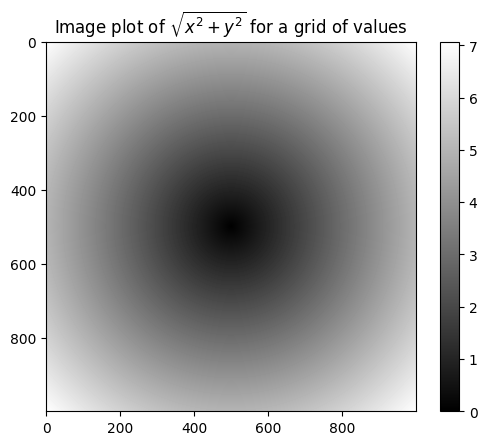

In [29]:
plt.imshow(z, cmap=plt.cm.gray); plt.colorbar()
plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")

# Expressing Conditional Logic as Array Operations

The numpy.where function is a vectorized version of the ternary expression x if condition else y. Suppose we had a boolean array and two arrays of values:

In [30]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])

In [31]:
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])

In [32]:
cond = np.array([True, False, True, True, False])

In [33]:
result = [(x if c else y) for x, y, c in zip(xarr, yarr, cond)]

In [34]:
result

[1.1, 2.2, 1.3, 1.4, 2.5]

This has multiple problems. First, it will not be very fast for large arrays (because all
the work is being done in interpreted Python code). Second, it will not work with
multidimensional arrays. With np.where you can write this very concisely:

In [35]:
resultl = np.where(cond, xarr, yarr)

In [36]:
result

[1.1, 2.2, 1.3, 1.4, 2.5]

The second and third arguments to np.where don’t need to be arrays; one or both of
them can be scalars. A typical use of where in data analysis is to produce a new array
of values based on another array. Suppose you had a matrix of randomly generated
data and you wanted to replace all positive values with 2 and all negative values with
–2. This is very easy to do with np.where:


In [37]:
arr = np.random.randn(4,4)

In [38]:
arr

array([[-3.02773245,  0.8007406 ,  1.52252156, -0.98053594],
       [ 1.60310717,  1.03073674, -0.94394434,  0.60209689],
       [ 0.20650243,  0.72059772, -0.57478174, -0.78010057],
       [ 0.1617148 , -1.39858017,  0.36739369,  0.74585104]])

In [39]:
arr > 0

array([[False,  True,  True, False],
       [ True,  True, False,  True],
       [ True,  True, False, False],
       [ True, False,  True,  True]])

In [40]:
np.where(arr > 0, 2, -2)

array([[-2,  2,  2, -2],
       [ 2,  2, -2,  2],
       [ 2,  2, -2, -2],
       [ 2, -2,  2,  2]])

You can combine scalars and arrays when using np.where. For example, I can replace
all positive values in arr with the constant 2 like so:

In [41]:
np.where(arr > 0, 2, arr)

array([[-3.02773245,  2.        ,  2.        , -0.98053594],
       [ 2.        ,  2.        , -0.94394434,  2.        ],
       [ 2.        ,  2.        , -0.57478174, -0.78010057],
       [ 2.        , -1.39858017,  2.        ,  2.        ]])

# Mathematical and Statistical Methods

A set of mathematical functions that compute statistics about an entire array or about
the data along an axis are accessible as methods of the array class. You can use aggre‐
gations (often called reductions) like sum, mean, and std (standard deviation) either by
calling the array instance method or using the top-level NumPy function.

Here I generate some normally distributed random data and compute some aggregate
statistics:

In [42]:
arr = np.random.randn(5, 4)

In [43]:
arr

array([[ 0.84322631, -0.31695666,  1.85419228,  0.71205097],
       [ 0.98362922, -0.62443167,  0.98626681, -0.56881146],
       [ 0.38261105, -0.38739577,  0.90167261, -0.43250212],
       [-0.42508365,  1.0088682 , -2.1309842 ,  0.55579689],
       [-1.07817484, -0.11334561,  0.14810271, -0.34972995]])

In [44]:
arr.mean()

0.09745005672384328

In [45]:
np.mean(arr)

0.09745005672384328

In [46]:
arr.sum()

1.9490011344768656

Functions like mean and sum take an optional axis argument that computes the statistic over the given axis, resulting in an array with one fewer dimension:

In [47]:
arr.mean(axis=1)

array([ 0.77312823,  0.19416322,  0.11609645, -0.24785069, -0.34828692])

In [48]:
arr.sum(axis=0)

array([ 0.70620809, -0.43326151,  1.75925021, -0.08319566])

Here, arr.mean(1) means “compute mean across the columns” where arr.sum(0)
means “compute sum down the rows.”

Other methods like cumsum and cumprod do not aggregate, instead producing an array
of the intermediate results:

In [49]:
arr = np.array([0,1,2,3,4,5,6,7])

In [ ]:
# This cumsum() element also called Cumulative sum, e.g (0+0 = 1, 0+1 = 1, 1+2 = 3, 3+3 = 6, 6+4 = 10, 10+5 = 15, 15+6 = 21, 21+7 = 28)
arr.cumsum()

array([ 0,  1,  3,  6, 10, 15, 21, 28])

In multidimensional arrays, accumulation functions like cumsum return an array of
the same size, but with the partial aggregates computed along the indicated axis
according to each lower dimensional slice:

In [51]:
arr = np.array([[0,1,2,],[3,4,5],[6,7,8]])

In [52]:
arr

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [53]:
arr.cumsum(axis=0)

array([[ 0,  1,  2],
       [ 3,  5,  7],
       [ 9, 12, 15]])

In [54]:
arr.cumprod(axis=1)

array([[  0,   0,   0],
       [  3,  12,  60],
       [  6,  42, 336]])

See Table 4-5 for a full listing. We’ll see many examples of these methods in action in
later chapters.

![alt text](Data/4.JPG)

# Methods for Boolean Arrays

Boolean values are coerced to 1 (True) and 0 (False) in the preceding methods. Thus,
sum is often used as a means of counting True values in a boolean array:


In [55]:
arr = np.random.randn(100)

In [56]:
(arr > 0).sum() # Number of Positive values

47

There are two additional methods, any and all, useful especially for boolean arrays.
any tests whether one or more values in an array is True, while all checks if every
value is True:

In [57]:
bools = np.array([False, False, True, False])

In [58]:
bools.any()

True

In [59]:
bools.all()

False

These methods also work with non-boolean arrays, where non-zero elements evalu‐
ate to True.

# Sorting

Like Python’s built-in list type, NumPy arrays can be sorted in-place with the sort
method:

In [60]:
arr = np.random.randn(6)

In [61]:
arr

array([-1.72219456, -0.70980948, -0.19074625,  0.23097645,  0.89110129,
        0.49668716])

In [62]:
arr.sort()

In [63]:
arr

array([-1.72219456, -0.70980948, -0.19074625,  0.23097645,  0.49668716,
        0.89110129])

You can sort each one-dimensional section of values in a multidimensional array inplace along an axis by passing the axis number to sort:

In [64]:
arr = np.random.randn(5, 3)

In [65]:
arr

array([[-0.21822794, -0.61047758, -2.22800988],
       [-0.02064574,  0.28781222, -0.75314984],
       [-2.20572815, -0.05656407,  1.29998475],
       [-0.79926596, -0.0642342 ,  1.46678334],
       [-0.71253814,  0.33152537, -0.00540792]])

In [66]:
arr.sort(1)

In [67]:
arr

array([[-2.22800988, -0.61047758, -0.21822794],
       [-0.75314984, -0.02064574,  0.28781222],
       [-2.20572815, -0.05656407,  1.29998475],
       [-0.79926596, -0.0642342 ,  1.46678334],
       [-0.71253814, -0.00540792,  0.33152537]])

The top-level method np.sort returns a sorted copy of an array instead of modifying
the array in-place. A quick-and-dirty way to compute the quantiles of an array is to
sort it and select the value at a particular rank:

In [68]:
large_arr = np.random.randn(1000)

In [69]:
large_arr.sort()

In [70]:
large_arr[int(0.05 * len(large_arr))] # 5% quantile

-1.704478175777811

# Unique and Other Set Logic

NumPy has some basic set operations for one-dimensional ndarrays. A commonly
used one is np.unique, which returns the sorted unique values in an array:

In [71]:
names = np.array(['Bob','Joe','Will','Bob','Will','Joe','Joe'])

In [72]:
np.unique(names)

array(['Bob', 'Joe', 'Will'], dtype='<U4')

In [73]:
ints = np.array([3,3,3,2,2,1,1,4,4])

In [74]:
np.unique(ints)

array([1, 2, 3, 4])

Contrast np.unique with the pure Python alternative:

In [76]:
sorted(set(names))

['Bob', 'Joe', 'Will']

Another function, np.in1d, tests membership of the values in one array in another,
returning a boolean array:

In [77]:
values = np.array([6,0,0,3,2,5,6])

In [79]:
np.in1d(values,[2,3,6])

array([ True, False, False,  True,  True, False,  True])

See Table 4-6 for a listing of set functions in NumPy.

Table 4-6. Array set operations

- unique(x)          (Compute the sorted, unique elements in x)

- intersect1d(x, y)  (Compute the sorted, common elements in x and y)

- union1d(x, y)      (Compute the sorted union of elements)

- in1d(x, y)         (Compute a boolean array indicating whether each element of      x is contained in y)

- setdiff1d(x, y)    (Set difference, elements in x that are not in y)

- setxor1d(x, y)     (Set symmetric differences; elements that are in either of the arrays, but not both)

# 4.4 File Input and Output with Arrays

NumPy is able to save and load data to and from disk either in text or binary format.
In this section I only discuss NumPy’s built-in binary format, since most users will
prefer pandas and other tools for loading text or tabular data (see Chapter 6 for much more).

np.save and np.load are the two workhorse functions for efficiently saving and load‐
ing array data on disk. Arrays are saved by default in an uncompressed raw binary
format with file extension .npy:


In [80]:
arr = np.arange(10)

In [81]:
np.save('some_array', arr)

In [82]:
np.load('some_array.npy')

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

You save multiple arrays in an uncompressed archive using np.savez and passing the
arrays as keyword arguments:

In [83]:
np.savez('array_archive.npz', a=arr, b=arr)

When loading an .npz file, you get back a dict-like object that loads the individual
arrays lazily:

In [84]:
arch = np.load('array_archive.npz')

In [86]:
arch['b']

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

If your data compresses well, you may wish to use numpy.savez_compressed instead:


In [87]:
np.savez_compressed('arrays_compressed.npz', a=arr, b=arr)

# **4.5 Linear Algebra**

Linear algebra, like matrix multiplication, decompositions, determinants, and other
square matrix math, is an important part of any array library. Unlike some languages
like MATLAB, multiplying two two-dimensional arrays with * is an element-wise
product instead of a matrix dot product. Thus, there is a function dot, both an array
method and a function in the numpy namespace, for matrix multiplication:

In [88]:
x = np.array([[1.,2.,3.], [4.,5.,6.]])

In [89]:
y = np.array([[6.,23.], [-1,7], [8,9]])

In [90]:
x

array([[1., 2., 3.],
       [4., 5., 6.]])

In [91]:
y

array([[ 6., 23.],
       [-1.,  7.],
       [ 8.,  9.]])

In [92]:
x.dot(y)

array([[ 28.,  64.],
       [ 67., 181.]])

x.dot(y) is equivalent to np.dot(x, y):

In [93]:
np.dot(x, y)

array([[ 28.,  64.],
       [ 67., 181.]])

A matrix product between a two-dimensional array and a suitably sized onedimensional array results in a one-dimensional array:

In [94]:
np.dot(x, np.ones(3))

array([ 6., 15.])

The @ symbol (as of Python 3.5) also works as an infix operator that performs matrix
multiplication:

In [95]:
x @ np.ones(3)

array([ 6., 15.])

numpy.linalg has a standard set of matrix decompositions and things like inverse
and determinant. These are implemented under the hood via the same industry-standard linear algebra libraries used in other languages like MATLAB and R, such as
BLAS, LAPACK, or possibly (depending on your NumPy build) the proprietary Intel
MKL (Math Kernel Library):

In [96]:
from numpy.linalg import inv, qr

In [97]:
X = np.random.randn(5,5)

In [98]:
mat = X.T.dot(X)

In [99]:
inv(mat)

array([[ 0.27503718,  0.20866246,  0.04180048, -0.12299481, -0.04067669],
       [ 0.20866246,  0.75760319,  0.07462743, -0.52124626, -0.45569833],
       [ 0.04180048,  0.07462743,  0.21220756, -0.08466654, -0.10512921],
       [-0.12299481, -0.52124626, -0.08466654,  0.47630625,  0.39238483],
       [-0.04067669, -0.45569833, -0.10512921,  0.39238483,  0.46378863]])

In [100]:
mat.dot(inv(mat))

array([[ 1.00000000e+00, -2.16761375e-16,  1.93068062e-17,
        -2.27040176e-16,  9.74472046e-17],
       [-6.12889553e-17,  1.00000000e+00, -4.10972413e-17,
         2.16611529e-16,  4.98892904e-16],
       [ 1.13456159e-16,  1.37337723e-16,  1.00000000e+00,
        -1.23459575e-16, -2.03275685e-16],
       [-1.60314051e-17, -2.33617371e-16,  1.14676917e-16,
         1.00000000e+00, -6.31632190e-16],
       [ 1.35134817e-16,  7.52809355e-16,  9.78930431e-17,
        -5.25244038e-16,  1.00000000e+00]])

In [101]:
q, r = qr(mat)

In [102]:
r

array([[ -7.85706938,   6.21562524,   3.94239208,  -2.54709354,
          9.44516104],
       [  0.        ,  -7.44768523,  -1.10216854, -11.91803977,
          2.45733326],
       [  0.        ,   0.        ,  -5.22129318,   0.88831013,
         -2.1749614 ],
       [  0.        ,   0.        ,   0.        ,  -6.73970176,
          7.09279573],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          1.30251462]])

The expression X.T.dot(X) computes the dot product of X with its transpose X.T.
See Table 4-7 for a list of some of the most commonly used linear algebra functions.

Table 4-7. Commonly used numpy.linalg functions

![alt text](../Data/5.JPG)

# **4.6 Pseudorandom Number Generation**

The numpy.random module supplements the built-in Python random with functions
for efficiently generating whole arrays of sample values from many kinds of probabil‐
ity distributions. For example, you can get a 4 × 4 array of samples from the standard normal distribution using normal:

In [2]:
import numpy as np

In [3]:
samples = np.random.normal(size=(4,4))

In [4]:
samples

array([[-0.19572608,  0.7053309 , -0.41002209, -0.62684055],
       [ 0.78853084,  0.78691698,  0.4973389 , -0.60575325],
       [-1.02048552, -1.28506016, -1.39006123, -1.68144295],
       [ 0.16717457, -1.18531474,  0.73546876,  0.95122206]])

Python’s built-in random module, by contrast, only samples one value at a time. As
you can see from this benchmark, numpy.random is well over an order of magnitude
faster for generating very large samples:

In [5]:
from random import normalvariate

In [6]:
N = 1000000

In [7]:
%timeit samples = [normalvariate(0,1) for _ in range(N)]

1.26 s ± 44.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [8]:
%timeit np.random.normal(size=N)

50.5 ms ± 7.02 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


We say that these are pseudorandom numbers because they are generated by an algo‐
rithm with deterministic behavior based on the seed of the random number genera‐
tor. You can change NumPy’s random number generation seed using **np.random.seed:**

In [9]:
np.random.seed(1234)

The data generation functions in numpy.random use a global random seed. To avoid
global state, you can use **numpy.random.RandomState** to create a random number
generator isolated from others:


In [10]:
rng = np.random.RandomState(1234)

In [11]:
rng.randn(10)

array([ 0.47143516, -1.19097569,  1.43270697, -0.3126519 , -0.72058873,
        0.88716294,  0.85958841, -0.6365235 ,  0.01569637, -2.24268495])

See Table 4-8 for a partial list of functions available in numpy.random. I’ll give some
examples of leveraging these functions’ ability to generate large arrays of samples all
at once in the next section

Table 4-8. Partial list of numpy.random functions


![alt text](Data/6.JPG)

# 4.7 Example: Random Walks

The simulation of random walks provides an illustrative application of utilizing array operations. Let’s first consider a simple random walk starting at 0 with steps of 1 and –1 occurring with equal probability.

Here is a pure Python way to implement a single random walk with 1,000 steps using
the built-in random module:


In [13]:
import random
position = 0
walk = [position]
steps = 1000
for i in range(steps):
    step = 1 if random.randint(0,1) else -1
    position += step
    walk.append(position)

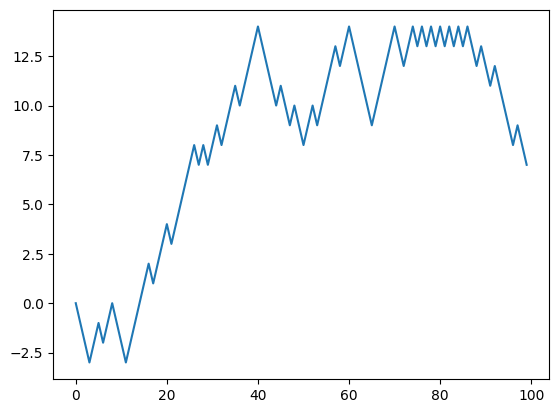

In [15]:
import matplotlib.pyplot as plt
plt.plot(walk[:100])

You might make the observation that walk is simply the cumulative sum of the ran‐
dom steps and could be evaluated as an array expression. Thus, I use the np.random
module to draw 1,000 coin flips at once, set these to 1 and –1, and compute the
cumulative sum:

In [20]:
nsteps = 1000

In [23]:
draws = np.random.randint(0, 2, size=nsteps)

In [24]:
steps = np.where(draws > 0, 1, -1)

In [25]:
walk = steps.cumsum()

From this we can begin to extract statistics like the minimum and maximum value
along the walk’s trajectory:

In [28]:
walk.min()

1

In [29]:
walk.max()

47

A more complicated statistic is the first crossing time, the step at which the random
walk reaches a particular value. Here we might want to know how long it took the
random walk to get at least 10 steps away from the origin 0 in either direction.
np.abs(walk) >= 10 gives us a boolean array indicating where the walk has reached
or exceeded 10, but we want the index of the first 10 or –10. Turns out, we can com‐
pute this using argmax, which returns the first index of the maximum value in the
boolean array (True is the maximum value):

In [30]:
(np.abs(walk) >= 10).argmax()

21

Note that using argmax here is not always efficient because it always makes a full scan
of the array. In this special case, once a True is observed we know it to be the maxi‐
mum value.

## **Simulating Many Random Walks at Once**

If your goal was to simulate many random walks, say 5,000 of them, you can generate
all of the random walks with minor modifications to the preceding code. If passed a
2-tuple, the numpy.random functions will generate a two-dimensional array of draws,
and we can compute the cumulative sum across the rows to compute all 5,000 ran‐
dom walks in one shot:

In [31]:
nwalks = 5000

In [32]:
nsteps = 1000

In [33]:
draws = np.random.randint(0, 2, size=(nwalks, nsteps)) # 0 or 1

In [34]:
steps = np.where(draws > 0, 1, -1)

In [35]:
walks = steps.cumsum(1)

In [36]:
walks

array([[  1,   0,   1, ...,  40,  41,  42],
       [  1,   2,   3, ..., -26, -27, -28],
       [ -1,  -2,  -3, ..., -12, -13, -12],
       ...,
       [  1,   2,   1, ...,   2,   1,   0],
       [ -1,  -2,  -3, ...,  32,  33,  34],
       [ -1,   0,   1, ...,  -6,  -5,  -4]])

Now, we can compute the maximum and minimum values obtained over all of the
walks:

In [37]:
walks.max()

122

In [38]:
walks.min()

-128

Out of these walks, let’s compute the minimum crossing time to 30 or –30. This is
slightly tricky because not all 5,000 of them reach 30. We can check this using the any
method:

In [39]:
hits30 = (np.abs(walks) >= 30).any(1)

In [40]:
hits30

array([ True,  True,  True, ..., False,  True, False])

In [41]:
hits30.sum() # Number that hit 30 or -30

3367

We can use this boolean array to select out the rows of walks that actually cross the
absolute 30 level and call argmax across axis 1 to get the crossing times:

In [42]:
crossing_times = (np.abs(walks[hits30]) >= 30).argmax(1)

In [43]:
crossing_times.mean()

510.1095931095931

Feel free to experiment with other distributions for the steps other than equal-sized
coin flips. You need only use a different random number generation function, like
normal to generate normally distributed steps with some mean and standard
deviation:

In [44]:
steps = np.random.normal(loc=0, scale=0.25, size=(nwalks, nsteps))

In [45]:
steps

array([[-0.04658199, -0.09601349,  0.35214427, ...,  0.10662353,
         0.36407567, -0.41932138],
       [ 0.45283878, -0.08752008, -0.24881766, ...,  0.15254953,
        -0.30402767,  0.35640316],
       [ 0.03885361,  0.2581173 ,  0.2547337 , ..., -0.14611522,
        -0.08702994,  0.09503463],
       ...,
       [ 0.78444227, -0.17341654,  0.2258262 , ...,  0.01966654,
         0.38198746, -0.38018986],
       [ 0.47667883,  0.1465151 ,  0.29799204, ..., -0.13227789,
        -0.10443224,  0.21326199],
       [ 0.20119019,  0.03425703,  0.12454794, ..., -0.17508571,
         0.53876384, -0.16232116]])